# Stage 1 — Data Exploration
**Project:** Gendered Citation Networks in French Electoral Manifestos

**Goal:** Load the Archelec manifesto texts, understand their structure, and produce descriptive statistics for the paper.

By the end of this notebook you will know:
- How many manifestos exist per election year
- What a manifesto looks like (text quality, length, OCR noise)
- The filename naming convention (we'll use it to link texts to metadata)

## 0. Setup

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from collections import Counter

# Root of your project
PROJECT_ROOT = Path("..")
TEXT_ROOT    = PROJECT_ROOT / "data" / "archelec_repo" / "text_files"

ELECTION_YEARS = ["1973", "1978", "1981", "1988", "1993"]

print("Text root exists:", TEXT_ROOT.exists())

Text root exists: True


## 1. Load all manifesto texts

Each `.txt` file = **one complete manifesto for one candidate**.  
The filename IS the candidate ID and matches the `id` field in the metadata directly.  
Example: `EL102_L_1978_03_001_01_1_PF_01.txt` = candidate 01 in dept 001, circ 01, tour 1, 1978 legislative election.

In [2]:
records = []

for year in ELECTION_YEARS:
    folder = TEXT_ROOT / year / "legislatives"
    if not folder.exists():
        print(f"Missing: {folder}")
        continue
    for fpath in sorted(folder.glob("*.txt")):
        try:
            text = fpath.read_text(encoding="utf-8", errors="replace")
        except Exception:
            text = ""
        records.append({
            "year":         year,
            "candidate_id": fpath.stem,   # full filename without .txt = matches metadata 'id'
            "text":         text,
            "n_words":      len(text.split()),
        })

df_manifestos = pd.DataFrame(records)
print(f"Total manifestos: {len(df_manifestos):,}")
print(f"\nManifestos per year:")
print(df_manifestos.groupby("year").size())
df_manifestos.head(3)

Total manifestos: 21,697

Manifestos per year:
year
1973    3921
1978    5030
1981    3182
1988    3628
1993    5936
dtype: int64


,year,candidate_id,text,n_words
0,1973,EL065_L_1973_03_001_01_1_PF_01,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,492
1,1973,EL065_L_1973_03_001_01_1_PF_02,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...,828
2,1973,EL065_L_1973_03_001_01_1_PF_03,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...,390


## 2. Join manifestos with metadata

We join on `candidate_id` (from filename) = `id` (from metadata) to attach gender and party info to each manifesto.

In [3]:
METADATA_PATH = PROJECT_ROOT / "data" / "archelec_metadata_full.csv"
df_meta = pd.read_csv(METADATA_PATH, sep=",", encoding="utf-8", low_memory=False)

# Filter to legislative elections only
df_meta_leg = df_meta[df_meta["subject"].str.contains("législatives", na=False)].copy()
df_meta_leg["year"] = pd.to_datetime(df_meta_leg["date"]).dt.year.astype(str)
df_meta_leg = df_meta_leg[df_meta_leg["year"].isin(ELECTION_YEARS)]

# Join: candidate_id (text) = id (metadata)
df = df_manifestos.merge(
    df_meta_leg[["id", "titulaire-sexe", "titulaire-soutien", "titulaire-profession", "year", "departement-nom"]],
    left_on="candidate_id",
    right_on="id",
    how="left"
)

print(f"Manifestos with metadata match: {df['titulaire-sexe'].notna().sum():,} / {len(df):,}")
print(f"\nGender distribution in our corpus:")
print(df["titulaire-sexe"].value_counts())
print(f"\n% female in corpus: {(df['titulaire-sexe'] == 'femme').mean()*100:.1f}%")

Manifestos with metadata match: 21,167 / 21,697

Gender distribution in our corpus:
titulaire-sexe
homme            18171
femme             2160
non déterminé      836
Name: count, dtype: int64

% female in corpus: 10.0%


## 3. Evolution of Female Candidates Over Time

How has the share of female candidates evolved across all legislative elections (1958–1993)?
The stars mark the 5 election years for which we have manifesto text — our study window.

In [ ]:
# Use full metadata (all legislative elections, not just our 5 years)
df_all_leg = df_meta[df_meta["subject"].str.contains("législatives", na=False)].copy()
df_all_leg["year"] = pd.to_datetime(df_all_leg["date"]).dt.year

pct_female = (
    df_all_leg.groupby("year")["titulaire-sexe"]
    .apply(lambda x: (x == "femme").sum() / len(x) * 100)
    .reset_index(name="pct_female")
)

study_years = [1973, 1978, 1981, 1988, 1993]
study_points = pct_female[pct_female["year"].isin(study_years)]

plt.figure(figsize=(11, 4))
plt.plot(pct_female["year"], pct_female["pct_female"],
         marker="o", color="coral", linewidth=2, markersize=5, label="All legislative elections")
plt.fill_between(pct_female["year"], pct_female["pct_female"], alpha=0.12, color="coral")

# Highlight study years with stars
plt.scatter(study_points["year"], study_points["pct_female"],
            marker="*", s=300, color="darkred", zorder=5, label="Study years (text available)")

plt.title("% Female candidates in French legislative elections (1958–1993)", fontsize=12)
plt.xlabel("Year")
plt.ylabel("% Female candidates")
plt.xticks(pct_female["year"], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_female_evolution.png", dpi=150)
plt.show()

print(pct_female.to_string(index=False))

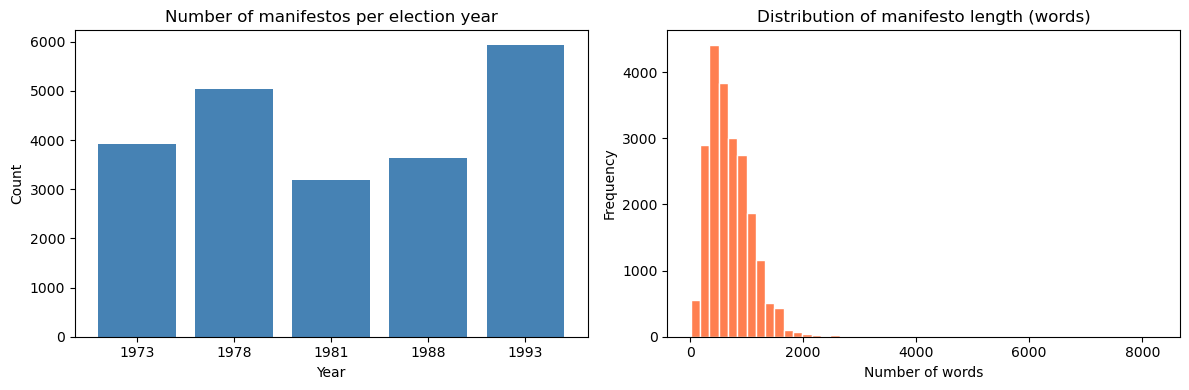


Word count summary:
count    21697.0
mean       699.0
std        378.0
min          9.0
25%        424.0
50%        626.0
75%        911.0
max       8255.0
Name: n_words, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_manifestos.groupby("year").size()
axes[0].bar(counts.index, counts.values, color="steelblue")
axes[0].set_title("Number of manifestos per election year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

axes[1].hist(df_manifestos["n_words"], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Distribution of manifesto length (words)")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_descriptive.png", dpi=150)
plt.show()

print("\nWord count summary:")
print(df_manifestos["n_words"].describe().round(0))

In [6]:
sample = df_manifestos.sample(1, random_state=42).iloc[0]
print(f"Year: {sample.year} | Words: {sample.n_words}")
print("-" * 60)
print(sample.text[:800])

Year: 1973 | Words: 1023
------------------------------------------------------------
4ème Circonscription SELESTAT-ERSTEIN
ELECTIONS LEGISLATIVES 1973
une majorité pour la France
Mit DE GAULLE gestern Mit G. POMPIDOU, heute und morgen
Werte Wählerinnen und Wähler !
Ein herzlicher und aufrichtiger Dank
all denjenigen die mir, so zahlreich, am letzten Sonntag, einmal mehr Ihr Vertrauen ausge- sprochen haben.
Mehr als 24.000
Wählerinnen und Wähler haben mir erneut Ihr Vertrauen geschenkt und verlangen somit die Fortsetzung einer Politik des sozialen Fortschritts und das Verfolgen eines einzigen und gleichen Zieles :
- Freiheit und Demokratie sollen garantiert sein,
- Die Entwicklung unseres Landes in einem europäischen und liberalen Rahmen muss gesichert sein, damit Jeder besser leben kann,
- Die Regionalisation muss tiefgreifender werden, sowie es von General De GAULLE verla


In [ ]:
def ocr_noise_score(text):
    if len(text) == 0:
        return 0
    noise = sum(1 for c in text if not c.isalpha() and not c.isspace())
    return noise / len(text)

df_manifestos["ocr_noise"] = df_manifestos["text"].apply(ocr_noise_score)

print("OCR noise score by year (lower = cleaner):")
print(df_manifestos.groupby("year")["ocr_noise"].mean().round(3))

## 8. Coverage Analysis: Text Files vs Metadata

Not every candidate who ran has a surviving digitized manifesto.
Here we compare candidates in the metadata vs candidates with actual text files.
This is a key limitation to report in the paper.

=== Coverage: text files vs metadata ===
      in_metadata  with_text  matched  coverage_%
1973         3843       3921     3843       100.0
1978         4830       5030     4827        99.9
1981         3121       3182     3121       100.0
1988         3540       3628     3539       100.0
1993         5837       5936     5837       100.0


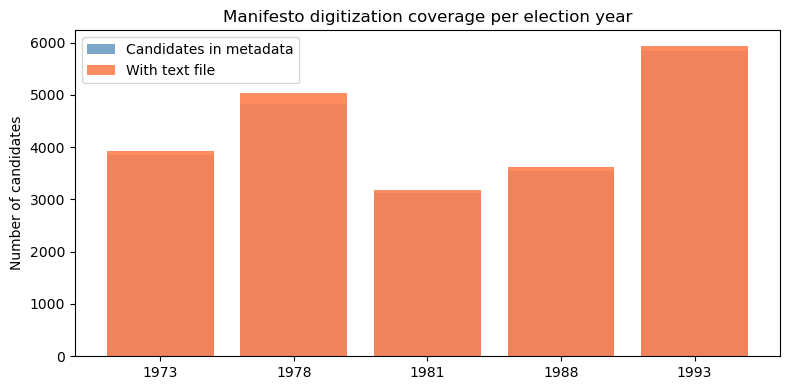

In [8]:
# Candidates in metadata for our 5 years
meta_counts = df_meta_leg.groupby("year").size().rename("in_metadata")

# Candidates with text files
text_counts = df_manifestos.groupby("year").size().rename("with_text")

# Matched (have both text and metadata)
matched_counts = df[df["titulaire-sexe"].notna()].groupby("year_x").size().rename("matched")

coverage = pd.concat([meta_counts, text_counts, matched_counts], axis=1)
coverage["coverage_%"] = (coverage["matched"] / coverage["in_metadata"] * 100).round(1)

print("=== Coverage: text files vs metadata ===")
print(coverage)

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(coverage))
ax.bar(x, coverage["in_metadata"], label="Candidates in metadata", color="steelblue", alpha=0.7)
ax.bar(x, coverage["with_text"], label="With text file", color="coral", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(coverage.index)
ax.set_title("Manifesto digitization coverage per election year")
ax.set_ylabel("Number of candidates")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_coverage.png", dpi=150)
plt.show()

## 9. Gender Bias in Digitization Coverage

An important question: is the digitization coverage equal across genders?
If male candidates are more likely to have a surviving text file than female candidates,
our corpus is doubly biased — fewer women AND lower coverage of women.
This must be reported as a limitation.

=== Digitization coverage by gender ===
titulaire-sexe  with_text  total  coverage_%
         femme       2160   2161       100.0
         homme      18171  18174       100.0
 non déterminé        836    836       100.0


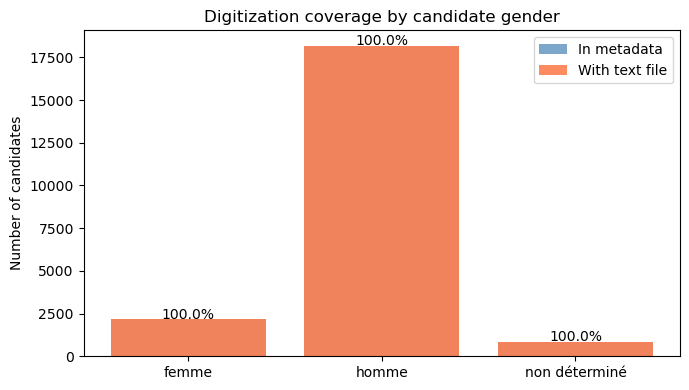

In [9]:
# Coverage by gender using the joined dataframe
coverage_by_gender = (
    df.groupby("titulaire-sexe")["candidate_id"]
    .count()
    .rename("with_text")
    .reset_index()
)

# Total per gender in metadata
total_by_gender = (
    df_meta_leg.groupby("titulaire-sexe")["id"]
    .count()
    .rename("total")
    .reset_index()
)

gender_cov = coverage_by_gender.merge(total_by_gender, on="titulaire-sexe")
gender_cov["coverage_%"] = (gender_cov["with_text"] / gender_cov["total"] * 100).round(1)

print("=== Digitization coverage by gender ===")
print(gender_cov.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(gender_cov))
ax.bar(x, gender_cov["total"], label="In metadata", color="steelblue", alpha=0.7)
ax.bar(x, gender_cov["with_text"], label="With text file", color="coral", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(gender_cov["titulaire-sexe"])
ax.set_title("Digitization coverage by candidate gender")
ax.set_ylabel("Number of candidates")
ax.legend()
for i, row in gender_cov.iterrows():
    ax.text(i, row["with_text"] + 30, f"{row['coverage_%']}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "fig_coverage_by_gender.png", dpi=150)
plt.show()